In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/LayoutLM_Project/data_subset.zip" -d "/content/"


replace /content/data_subset/pre2.py? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/data_subset/test/advertisement/00001014.tif? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
# Copy 3 file txt ra ngoài cho dễ quản lý
!cp /content/drive/MyDrive/LayoutLM_Project/*.txt /content/

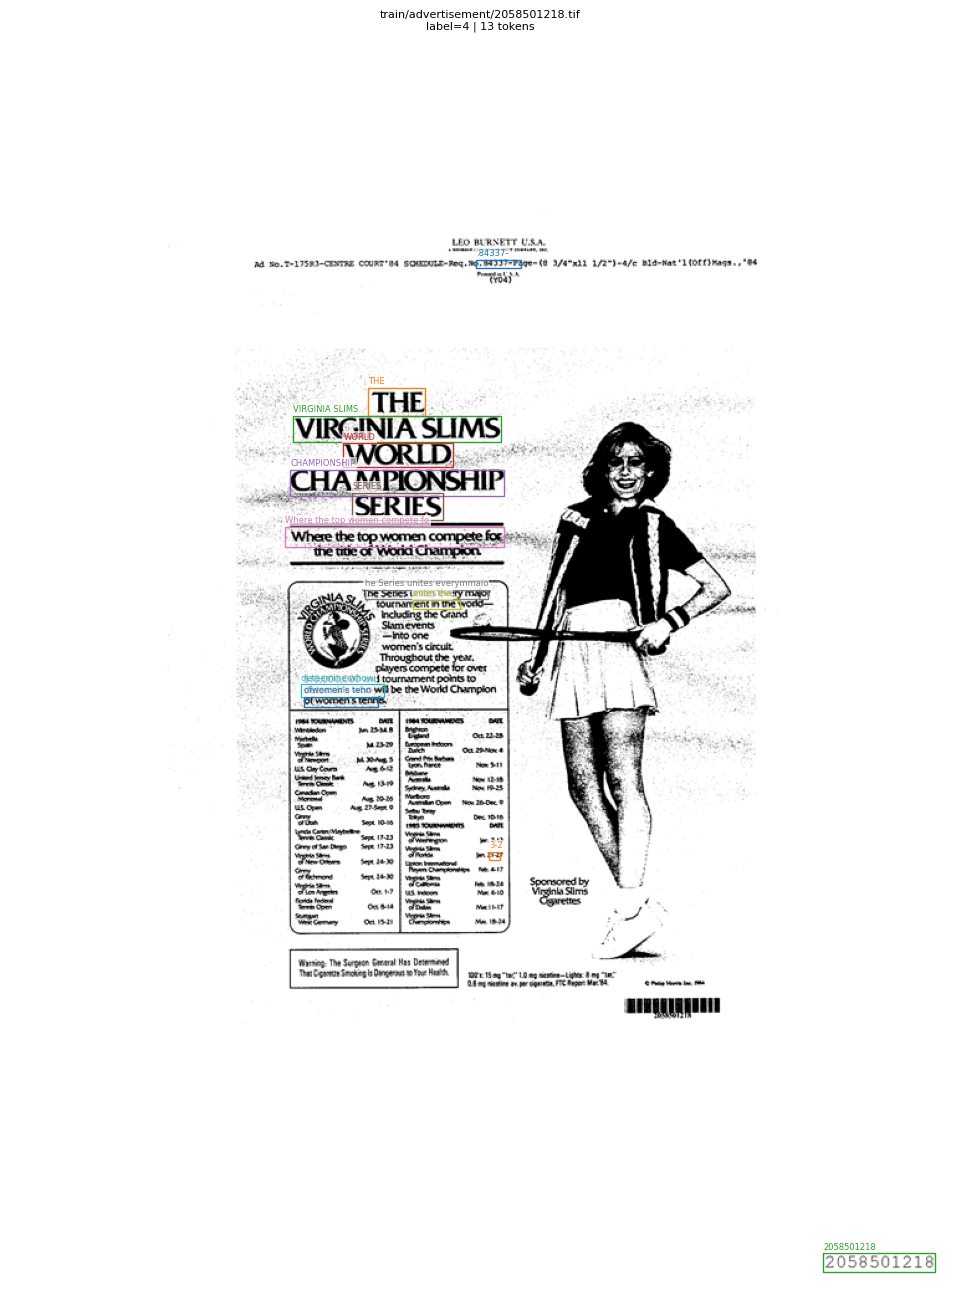

Words: ['.84337-', 'THE', 'VIRGINIA SLIMS', 'WORLD', 'CHAMPIONSHIP', 'SERIES', 'Where the top women compete fo', 'he Series unites everymmaio', 'entin the', 'deteemine whowi', "ofwomen's tenn", '3-2', '2058501218']


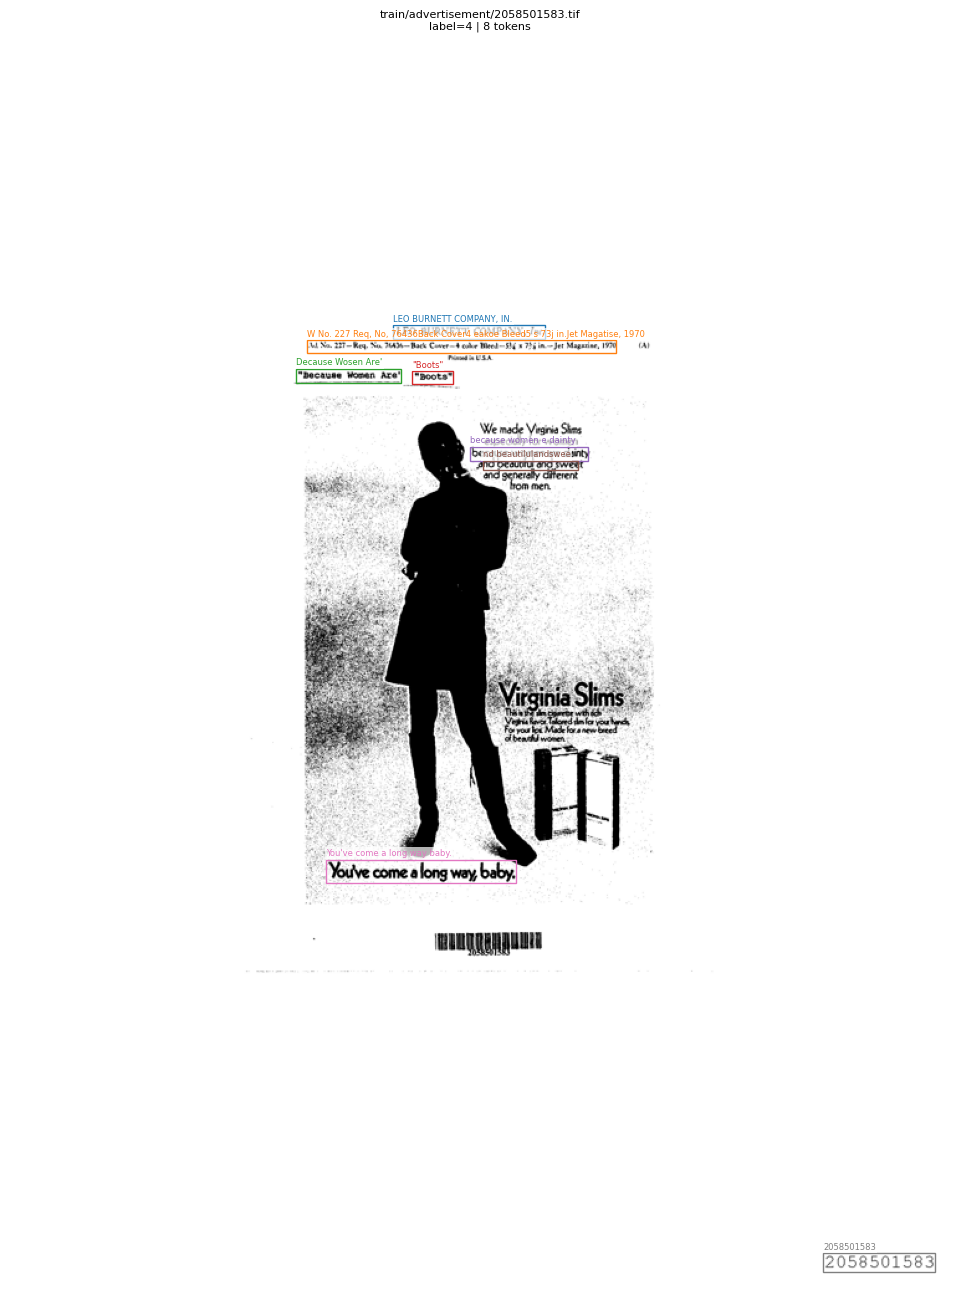

Words: ['LEO BURNETT COMPANY, IN.', 'W No. 227 Req, No, 76436Back Cover4 eakoe Bleed5 s 73j in.Jet Magatise, 1970', "Decause Wosen Are'", '"Boots"', 'because women e dainty', 'nd beautilulandswee', "You've come a long way baby.", '2058501583']


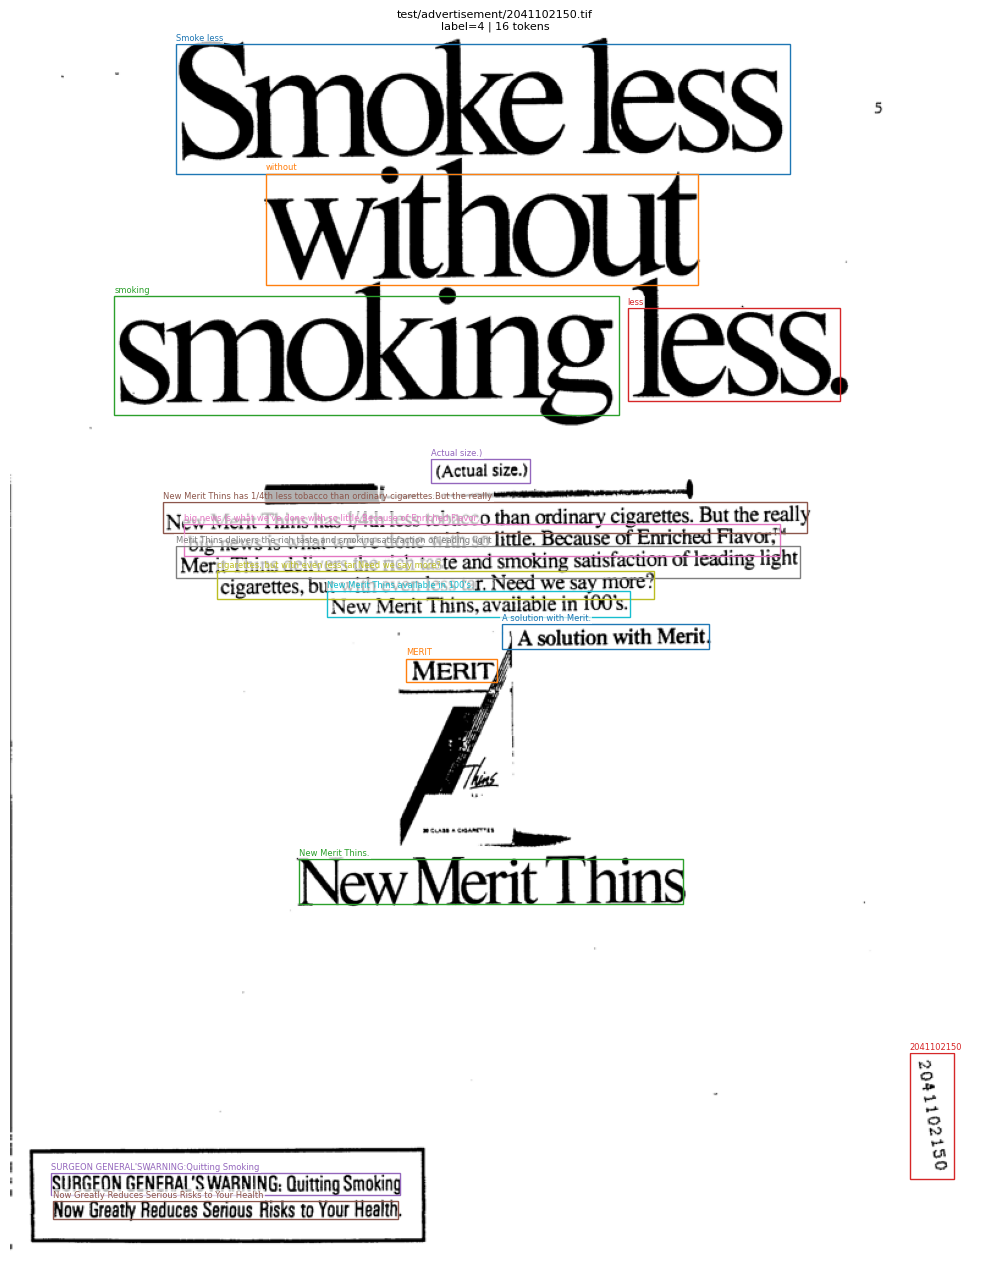

Words: ['Smoke less', 'without', 'smoking', 'less', 'Actual size.)', 'New Merit Thins has 1/4th less tobacco than ordinary cigarettes.But the really', "big news is what we've done with so little.Because of Enriched Flavor,", 'Merit Thins delivers the rich taste and smoking satisfaction of leading light', 'cigarettes, but with even less tar.Need we say more?', "New Merit Thins available in 100's.", 'A solution with Merit.', 'MERIT', 'New Merit Thins.', '2041102150', "SURGEON GENERAL'SWARNING:Quitting Smoking", 'Now Greatly Reduces Serious Risks to Your Health']


In [ ]:
import json, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image

DRIVE          = Path("/content/drive/MyDrive/LayoutLM_Project/processed_data")
IMAGE_BASE_DIR = Path("/content/data_subset")

def visualize_ocr(index=0, split="train"):
    # Đọc row từ JSONL
    with open(DRIVE / f"{split}_metadata.jsonl") as f:
        for i, line in enumerate(f):
            if i == index:
                row = json.loads(line)
                break

    words  = row["words"]
    bboxes = row["bboxes"]
    img    = np.array(Image.open(IMAGE_BASE_DIR / row["file_name"]).convert("RGB"))
    h, w   = img.shape[:2]

    # Scale bbox [0,1000] → pixel
    def to_px(b):
        return int(b[0]/1000*w), int(b[1]/1000*h), \
               int(b[2]/1000*w), int(b[3]/1000*h)

    fig, ax = plt.subplots(figsize=(10, 13))
    ax.imshow(img, cmap="gray")
    ax.set_title(
        f"{row['file_name']}\nlabel={row['label']} | {len(words)} tokens",
        fontsize=8
    )

    colors = plt.cm.tab10.colors
    for i, (word, bbox) in enumerate(zip(words, bboxes)):
        x1, y1, x2, y2 = to_px(bbox)
        c = colors[i % len(colors)]
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=1, edgecolor=c, facecolor="none"
        ))
        ax.text(x1, y1-3, word, fontsize=6, color=c,
                bbox=dict(fc="white", ec="none", alpha=0.7, pad=1))

    ax.axis("off")
    plt.tight_layout()
    plt.show()
    print("Words:", words)

# ── Chạy ──────────────────────────────────────────────────────────────────
visualize_ocr(index=500,  split="train")
visualize_ocr(index=509, split="train")
visualize_ocr(index=36,  split="test")

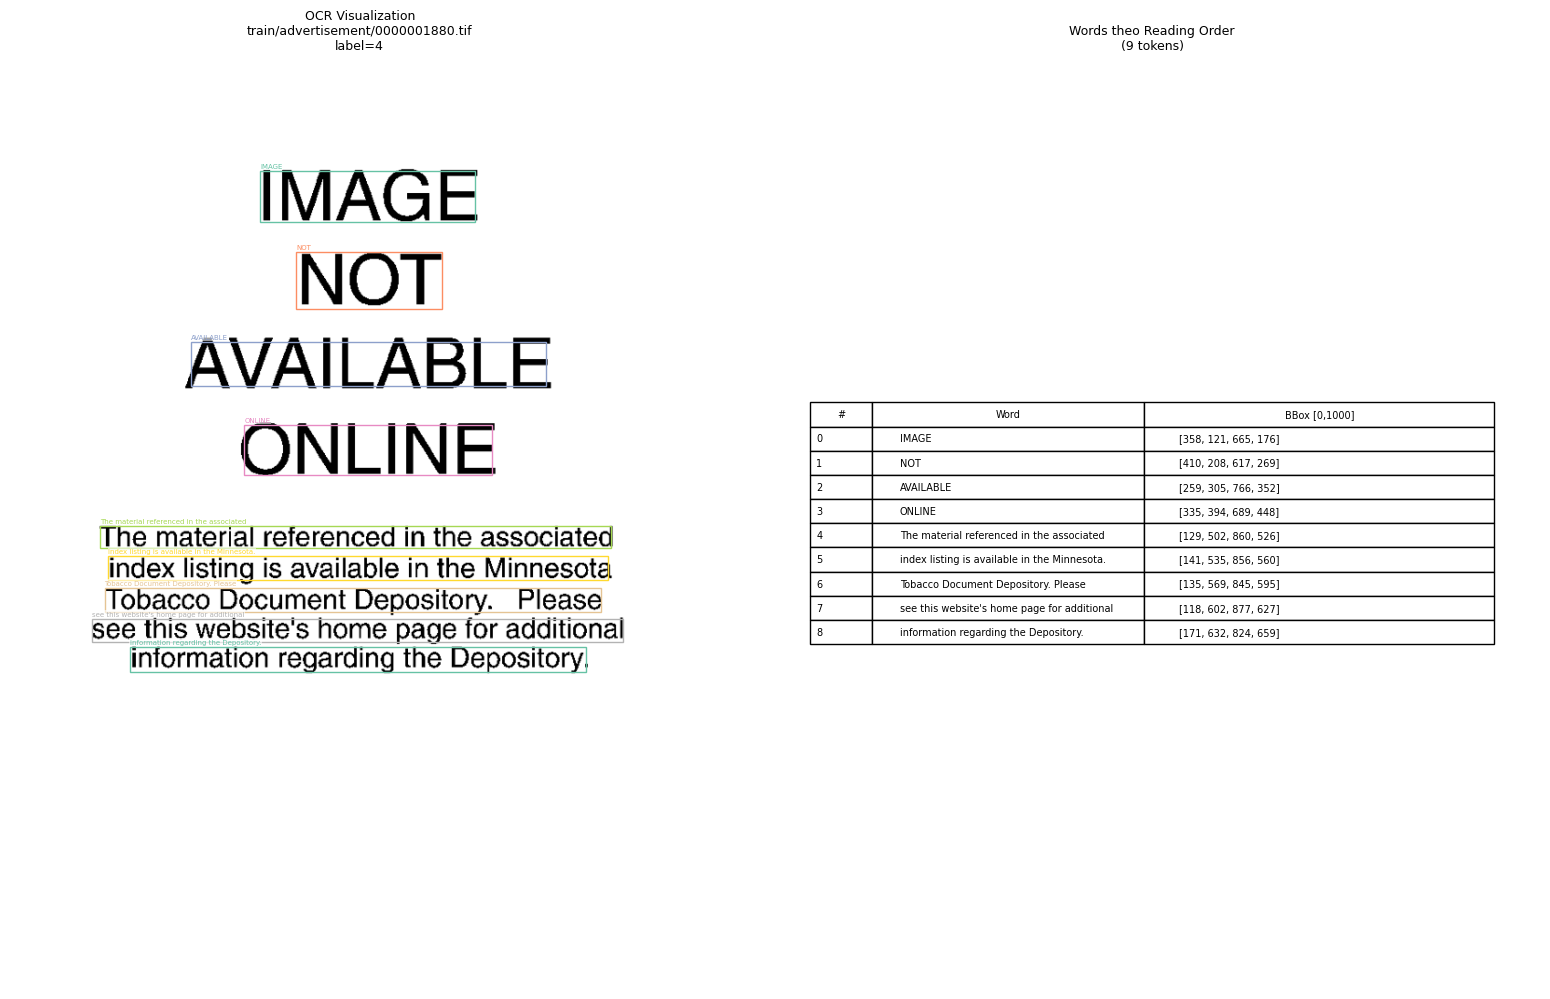

File    : train/advertisement/0000001880.tif
Label   : 4
Tokens  : 9
5 đầu   : ['IMAGE', 'NOT', 'AVAILABLE', 'ONLINE', 'The material referenced in the associated']
5 cuối  : ['The material referenced in the associated', 'index listing is available in the Minnesota.', 'Tobacco Document Depository. Please', "see this website's home page for additional", 'information regarding the Depository.']


In [ ]:
# CELL VISUALIZE — Kiểm tra OCR output trực quan
import cv2
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
import numpy as np

DRIVE          = Path("/content/drive/MyDrive/LayoutLM_Project/processed_data")
IMAGE_BASE_DIR = Path("/content/data_subset")

def visualize_ocr(jsonl_path: Path, index: int = 0):
    """
    Vẽ bbox + text lên ảnh gốc để kiểm tra OCR có đúng không.
    index: dòng thứ mấy trong JSONL muốn kiểm tra
    """
    # Đọc 1 row từ JSONL
    with open(jsonl_path) as f:
        for i, line in enumerate(f):
            if i == index:
                row = json.loads(line)
                break

    img_path = IMAGE_BASE_DIR / row["file_name"]
    words    = row["words"]
    bboxes   = row["bboxes"]   # đang ở [0, 1000]
    label    = row["label"]

    # Load ảnh gốc
    img = np.array(Image.open(img_path).convert("RGB"))
    h, w = img.shape[:2]

    # Scale bbox từ [0,1000] về pixel thực
    def to_pixel(bbox):
        x1, y1, x2, y2 = bbox
        return (int(x1/1000*w), int(y1/1000*h),
                int(x2/1000*w), int(y2/1000*h))

    # Vẽ
    fig, axes = plt.subplots(1, 2, figsize=(16, 10))

    # ── Bên trái: ảnh với bbox ────────────────────────────────────────────
    ax = axes[0]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"OCR Visualization\n{row['file_name']}\nlabel={label}",
                 fontsize=9)

    colors = plt.cm.Set2.colors   # màu khác nhau cho dễ nhìn
    for i, (word, bbox) in enumerate(zip(words, bboxes)):
        px1, py1, px2, py2 = to_pixel(bbox)
        color = colors[i % len(colors)]

        # Vẽ rectangle
        rect = patches.Rectangle(
            (px1, py1), px2-px1, py2-py1,
            linewidth=1, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)

        # Label text nhỏ phía trên box
        ax.text(px1, py1-2, word, fontsize=5,
                color=color, va="bottom",
                bbox=dict(boxstyle="square,pad=0.1",
                          fc="white", ec="none", alpha=0.6))

    ax.axis("off")

    # ── Bên phải: danh sách text theo reading order ───────────────────────
    ax2 = axes[1]
    ax2.axis("off")
    ax2.set_title(f"Words theo Reading Order\n({len(words)} tokens)", fontsize=9)

    # Hiển thị dạng bảng: index | word | bbox
    col_labels = ["#", "Word", "BBox [0,1000]"]
    table_data = [
        [str(i), w, str(b)]
        for i, (w, b) in enumerate(zip(words[:40], bboxes[:40]))
    ]
    if len(words) > 40:
        table_data.append(["...", f"(+{len(words)-40} tokens nữa)", ""])

    table = ax2.table(
        cellText    = table_data,
        colLabels   = col_labels,
        cellLoc     = "left",
        loc         = "center",
        colWidths   = [0.08, 0.35, 0.45],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(7)
    table.scale(1, 1.2)

    plt.tight_layout()
    plt.show()

    # Tóm tắt nhanh
    print(f"File    : {row['file_name']}")
    print(f"Label   : {label}")
    print(f"Tokens  : {len(words)}")
    print(f"5 đầu   : {words[:5]}")
    print(f"5 cuối  : {words[-5:]}")


# ── Chạy thử ─────────────────────────────────────────────────────────────
# Đổi index để xem ảnh khác nhau
visualize_ocr(DRIVE / "train_metadata.jsonl", index=0)

In [ ]:
# Đếm ảnh có words chứa "IMAGE NOT AVAILABLE"
import json
from pathlib import Path

DRIVE = Path("/content/drive/MyDrive/LayoutLM_Project/processed_data")

placeholder_count = 0
total = 0

with open(DRIVE / "train_metadata.jsonl") as f:
    for line in f:
        row = json.loads(line)
        total += 1
        text = " ".join(row["words"]).upper()
        if "IMAGE NOT AVAILABLE" in text:
            placeholder_count += 1

print(f"Placeholder: {placeholder_count}/{total} "
      f"({placeholder_count/total*100:.1f}%)")

Placeholder: 36/31929 (0.1%)


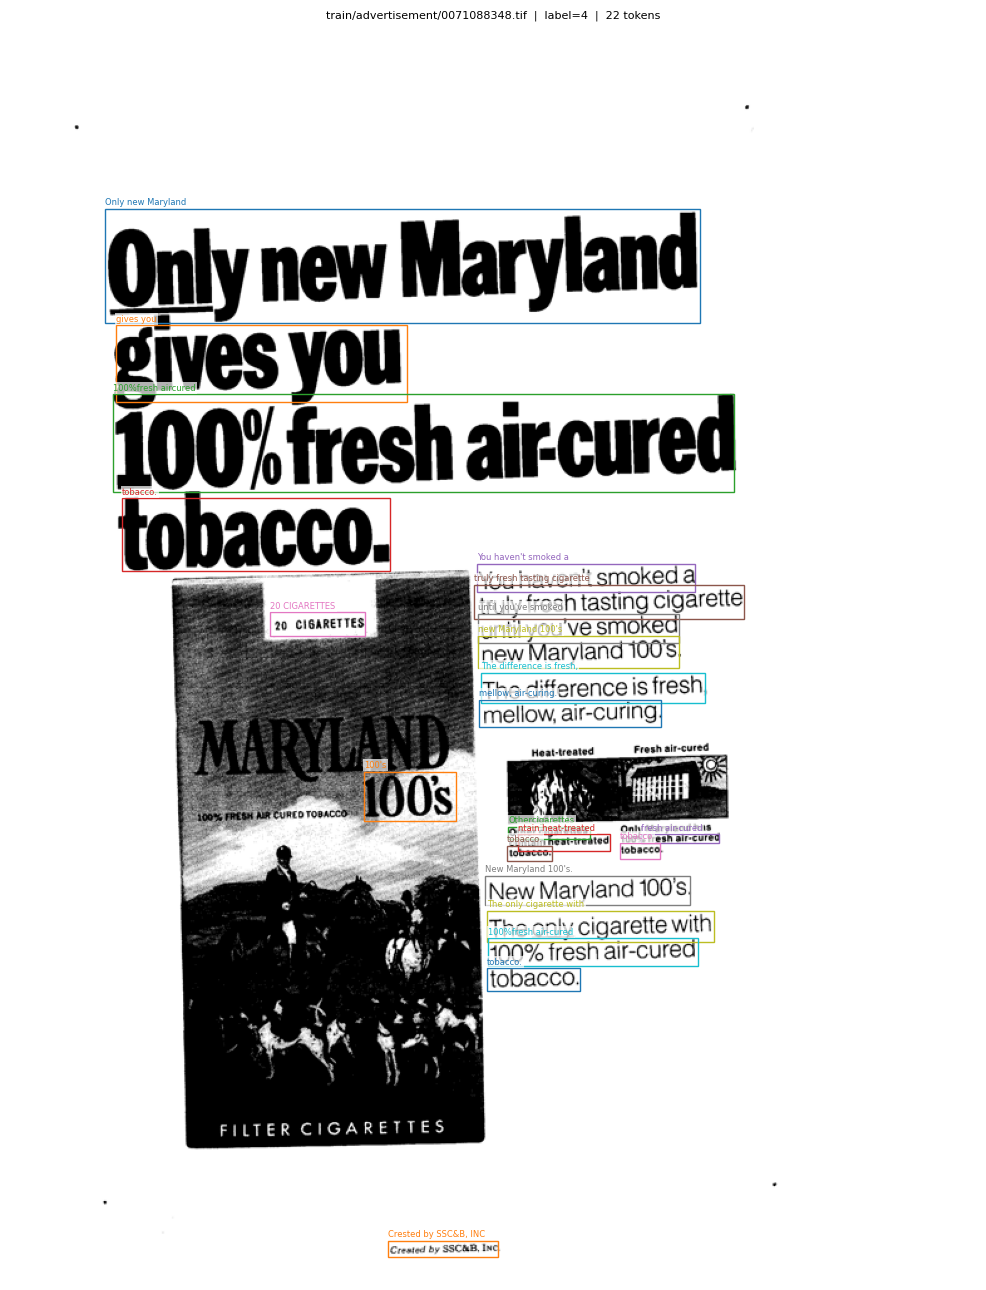

File   : train/advertisement/0071088348.tif
Label  : 4
Tokens : 22
Words  : ['Only new Maryland', 'gives you', '100%fresh aircured', 'tobacco.', "You haven't smoked a", 'truly fresh tasting cigarette', '20 CIGARETTES', "until you've smoked", "new Maryland 100's", 'The difference is fresh,', 'mellow, air-curing.', "100's", 'Othercigarettes', 'ntain heat-treated', 'fresh air-cured', 'tobacco.', 'tobacco', "New Maryland 100's.", 'The only cigarette with', '100%fresh air-cured', 'tobacco.', 'Crested by SSC&B, INC']


In [ ]:
import json, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image

DRIVE          = Path("/content/drive/MyDrive/LayoutLM_Project/processed_data")
IMAGE_BASE_DIR = Path("/content/data_subset")

def visualize_ocr(index=0, split="train"):
    # Đọc row từ JSONL
    jsonl = DRIVE / f"{split}_metadata.jsonl"
    with open(jsonl) as f:
        for i, line in enumerate(f):
            if i == index:
                row = json.loads(line)
                break

    words  = row["words"]
    bboxes = row["bboxes"]   # [0, 1000]

    # Load ảnh gốc
    img    = np.array(Image.open(IMAGE_BASE_DIR / row["file_name"]).convert("RGB"))
    h, w   = img.shape[:2]

    # Scale bbox về pixel
    def to_px(b):
        return int(b[0]/1000*w), int(b[1]/1000*h), \
               int(b[2]/1000*w), int(b[3]/1000*h)

    fig, ax = plt.subplots(figsize=(10, 13))
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{row['file_name']}  |  label={row['label']}  |  {len(words)} tokens",
                 fontsize=8)

    colors = plt.cm.tab10.colors
    for i, (word, bbox) in enumerate(zip(words, bboxes)):
        x1, y1, x2, y2 = to_px(bbox)
        color = colors[i % len(colors)]
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=1, edgecolor=color, facecolor="none"
        ))
        ax.text(x1, y1-3, word, fontsize=6, color=color,
                bbox=dict(fc="white", ec="none", alpha=0.7, pad=1))

    ax.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"File   : {row['file_name']}")
    print(f"Label  : {row['label']}")
    print(f"Tokens : {len(words)}")
    print(f"Words  : {words}")

# Đổi index để xem ảnh khác
visualize_ocr(index=100, split="train")

In [ ]:
#Chạy rồi restart session

import subprocess, sys

def run(cmd, allow_fail=False):
    """Chạy shell command, in output. Nếu allow_fail=True thì không raise khi lỗi."""
    print(f"\n>>> {cmd}")
    result = subprocess.run(
        cmd, shell=True, text=True,
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT
    )
    print(result.stdout[-3000:] if len(result.stdout) > 3000 else result.stdout)
    if result.returncode != 0 and not allow_fail:
        raise RuntimeError(f"Command failed (exit {result.returncode}): {cmd}")
    return result.returncode

# Bước 1: Gỡ tất cả phiên bản PaddlePaddle/PaddleOCR hiện có
run("pip uninstall -y paddleocr paddlepaddle paddlepaddle-gpu paddle2onnx"
    " 2>/dev/null || true", allow_fail=True)

# Bước 2: Cài PaddlePaddle GPU từ PyPI (không dùng mirror CN — không ổn định)
run("pip install -q paddlepaddle-gpu==2.6.2 -i https://pypi.org/simple/")

# Bước 3: Cài PaddleOCR 2.7.3 từ PyPI
run("pip install -q paddleocr==2.7.3 -i https://pypi.org/simple/")

# Bước 4: Ghim NumPy < 2.0
run("pip install -q 'numpy<2.0.0' --force-reinstall -i https://pypi.org/simple/")

# Bước 5: OpenCV headless (tránh lỗi Qt/GUI trên môi trường headless Colab)
run("pip uninstall -y opencv-python opencv-contrib-python 2>/dev/null || true",
    allow_fail=True)
run("pip install -q 'opencv-python-headless>=4.5,<4.9' -i https://pypi.org/simple/")

# Bước 6: Các thư viện phụ
run("pip install -q tqdm jsonlines -i https://pypi.org/simple/")

# Kiểm tra nhanh sau khi cài
print("\n" + "="*60)
print("Kiểm tra phiên bản vừa cài:")
run("python -c \""
    "import numpy as np; import cv2; "
    "print(f'  NumPy : {np.__version__}'); "
    "print(f'  OpenCV: {cv2.__version__}'); "
    "from paddleocr import PaddleOCR; "
    "print(f'  PaddleOCR: import OK')\"",
    allow_fail=True)

print("\n" + "="*60)
print("✅ Setup hoàn tất.")
print("⚠️  BẮT BUỘC: Runtime → Restart Runtime → rồi mới chạy Cell 2 & 3")
print("="*60)


>>> pip uninstall -y paddleocr paddlepaddle paddlepaddle-gpu paddle2onnx 2>/dev/null || true


>>> pip install -q paddlepaddle-gpu==2.6.2 -i https://pypi.org/simple/
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 758.9/758.9 MB 826.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.3 MB/s eta 0:00:00


>>> pip install -q paddleocr==2.7.3 -i https://pypi.org/simple/
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.0/780.0 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
import numpy as np
import cv2

print(f"NumPy  : {np.__version__}   (cần < 2.0)")
print(f"OpenCV : {cv2.__version__}  (cần < 4.9)")

assert tuple(int(x) for x in np.__version__.split(".")[:2]) < (2, 0), \
    "❌ NumPy vẫn là 2.x — chạy lại Cell 1 và Restart Runtime"

print("\n✅ Môi trường OK. Tiếp tục chạy Cell 3.")

NumPy  : 1.26.4   (cần < 2.0)
OpenCV : 4.8.1  (cần < 4.9)

✅ Môi trường OK. Tiếp tục chạy Cell 3.


In [ ]:
import re
import json
import logging
import unicodedata
import warnings
from collections import Counter
from pathlib import Path
from typing import Optional

import cv2
import numpy as np
from tqdm import tqdm
from paddleocr import PaddleOCR

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
log = logging.getLogger(__name__)


class Config:
    IMAGE_BASE_DIR = Path("/content/data_subset")
    OUTPUT_DIR     = Path("/content/drive/MyDrive/LayoutLM_Project/processed_data")

    CLASS_TO_LABEL = {
        "letter": 0, "form": 1, "email": 2, "handwritten": 3,
        "advertisement": 4, "scientific_report": 5,
        "scientific_publication": 6, "specification": 7,
        "file_folder": 8, "news_article": 9, "budget": 10,
        "invoice": 11, "presentation": 12, "questionnaire": 13,
        "resume": 14, "memo": 15,
    }

    # EDA: chữ vỡ nét ở 224/384px → chạy OCR trên ảnh chất lượng cao
    # EDA: aspect ratio ~0.77 (portrait) → KHÔNG crop, giữ nguyên tỉ lệ
    OCR_MAX_SIDE         : int   = 1024 #có thể cân nhắc phần lớn ảnh 1000 px
    CONFIDENCE_THRESHOLD : float = 0.6 #cao hơn sợ mất dữ liệu
    MIN_TOKEN_LENGTH     : int   = 2 #1 có thể là ký tự rác gây nhiễu

    # ── CLAHE
    # Làm rõ chữ trên ảnh scan mờ/ngả vàng — áp dụng trên kênh L-độ sáng
    CLAHE_CLIP_LIMIT : float = 2.0 # Mức trung bình ổn định
    CLAHE_TILE_GRID  : tuple = (8, 8) # Chia ảnh thành lưới 8×8 = 64 ô

    LINE_TOLERANCE  : int = 10 # Nếu 2 token lệch ≤ 10px theo trục y (trên-dưới) thì coi là cùng dòng

    # ── BBox normalization
    BBOX_NORM_SCALE : int = 1000  # Chuẩn hóa bbox về hệ tọa độ [0,1000] cho LayoutLMv3

    # ── Splits
    SPLITS = ["train", "val", "test"]


# TASK BUILDER — đọc từ folder structure
# (Thay thế load_tasks() dùng txt vì path trong txt không khớp thực tế)

def build_tasks(split: str, cfg: Config) -> list[tuple[str, str, str]]:
    """
    Đọc trực tiếp từ data_subset/{split}/{class_name}/*.tif

    Tại sao không dùng train.txt?
        Path trong txt: "imagesq/q/o/c/.../file.tif" (RVL-CDIP gốc 400k)
        Path thực tế  : "train/invoice/file.tif"     (subset đã giải nén)
        → Không khớp → dùng folder structure thay thế

    Returns:
        list of (abs_path, rel_path, label_str)
        rel_path = "train/invoice/xxx.tif" — dùng làm file_name trong JSONL
    """
    split_dir = cfg.IMAGE_BASE_DIR / split
    if not split_dir.exists():
        raise FileNotFoundError(f"Không tìm thấy: {split_dir}")

    tasks = []
    class_counts = Counter()

    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        label = cfg.CLASS_TO_LABEL.get(class_dir.name)
        if label is None:
            log.warning("Class không nhận dạng được, bỏ qua: %s", class_dir.name)
            continue
        for img_path in sorted(class_dir.glob("*.tif")):
            rel = str(img_path.relative_to(cfg.IMAGE_BASE_DIR))
            tasks.append((str(img_path), rel, str(label))) #tạo bộ 3 bỏ vào danh sách
            class_counts[class_dir.name] += 1

    # Kiểm tra cân bằng class
    if class_counts:
        counts = list(class_counts.values())
        min_c, max_c = min(counts), max(counts)
        ratio = max_c / min_c if min_c > 0 else float("inf")
        if ratio > 1.5:
            log.warning(
                "[%s] Class mất cân bằng! min=%d max=%d ratio=%.1f — "
                "cân nhắc WeightedRandomSampler khi train.",
                split, min_c, max_c, ratio
            )
        else:
            log.info("[%s] Class cân bằng tốt (ratio=%.2f)", split, ratio)

    log.info("[%s] %d ảnh | %d classes", split, len(tasks), len(class_counts))
    return tasks


# OCR ENGINE — PaddleOCR 2.7.3

def build_ocr_engine() -> PaddleOCR: # Khởi tạo PaddleOCR 2.7.3 stable trên Colab T4.
    log.info("Khởi tạo PaddleOCR...")
    engine = PaddleOCR(
        use_angle_cls = True, # Bật phát hiện xoay chữ
        lang          = "en",
        use_gpu       = True,
        show_log      = False,
        enable_mkldnn = False, # Tắt để tránh lỗi trên một số Colab session
    )
    log.info("PaddleOCR sẵn sàng.")
    return engine


# IMAGE BRANCH

def load_image(image_path: str, cfg: Config) -> Optional[np.ndarray]:
    """
    Load ảnh → BGR→RGB → resize giữ tỉ lệ → CLAHE.
    224×224 resize cho model branch bị bỏ vì:
        Lúc train, LayoutLMv3Processor nhận ảnh gốc và tự tạo pixel_values.
        Pre-resize ở đây không có tác dụng, chỉ tốn thêm bước.
    """
    img = cv2.imread(image_path)
    if img is None:
        return None

    # BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize giữ tỉ lệ nếu cần
    h, w = img.shape[:2]
    if max(h, w) > cfg.OCR_MAX_SIDE:
        scale = cfg.OCR_MAX_SIDE / max(h, w)
        img   = cv2.resize(img, (int(w * scale), int(h * scale)),
                           interpolation=cv2.INTER_AREA)

    # CLAHE trên kênh L (LAB)
    # Làm rõ chữ scan mờ mà không shift màu
    lab        = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l_ch, a, b = cv2.split(lab)
    clahe      = cv2.createCLAHE(
        clipLimit  = cfg.CLAHE_CLIP_LIMIT,
        tileGridSize = cfg.CLAHE_TILE_GRID,
    )
    merged = cv2.merge([clahe.apply(l_ch), a, b])
    img    = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    return img

# TOKEN CLEANING — kế thừa từ document_processor._clean_token()

def clean_token(text: str, min_len: int) -> str:
# Đảm bảo tính nhất quán.Dù OCR quét ra kiểu gì, chỉ có một định dạng duy nhất.
    text = unicodedata.normalize("NFC", text).strip() # Chuẩn hóa unicode và bỏ ký tự trống đầu cuối

    if len(text) < min_len:
        if not text.isdigit(): # Bỏ token quá ngắn trừ số
            return ""
# Phải chứa ít nhất 1 ký tự yêu cầu, ko thì trả về chuỗi rỗng
    if not re.search(r"[a-zA-Z0-9]", text):
        return ""

    return text

# READING ORDER SORT: Dạy máy tính cách đọc tài liệu

def sort_reading_order(tokens: list[dict], line_tol: int) -> list[dict]:
    if not tokens:
        return []

    for t in tokens:
        x1, y1, x2, y2 = t["bbox"]
        t["_yc"] = (y1 + y2) / 2 # Tâm theo trục y

    lines: list[list[dict]] = []

    # Duyệt token từ trên xuống (theo _yc)
    for tok in sorted(tokens, key=lambda t: t["_yc"]):
        placed = False
        for line in lines:
            # Tính vị trí dọc tb và nếu token gần dòng thì cùng dòng
            avg_y = sum(t["_yc"] for t in line) / len(line)
            if abs(tok["_yc"] - avg_y) <= line_tol:
                line.append(tok)
                placed = True
                break
        if not placed:
            lines.append([tok])

    # Sắp xếp theo trục X, trái sang phải
    for line in lines:
        line.sort(key=lambda t: t["bbox"][0])
    # Sắp xếp theo vị trí dọc trung bình, trên xuống dưới
    lines.sort(key=lambda ln: sum(t["_yc"] for t in ln) / len(ln))

    out = []
    for line in lines:
        for t in line:
            t.pop("_yc", None)
            out.append(t)
    return out


# BBOX NORMALIZATION: Chuẩn hóa bounding box từ hệ pixel sang hệ tọa độ [0, scale]

def normalize_bbox(bbox: list, img_w: int, img_h: int, scale: int) -> list:
    x1, y1, x2, y2 = bbox
    nb = [
        min(scale, max(0, int(x1 / img_w * scale))),
        min(scale, max(0, int(y1 / img_h * scale))),
        min(scale, max(0, int(x2 / img_w * scale))),
        min(scale, max(0, int(y2 / img_h * scale))),
    ]
    # Cân nhắc xử lý: nếu bbox chạm biên, cần xử lý thêm để tránh width=0
    if nb[0] >= nb[2]: nb[2] = min(scale, nb[0] + 1)
    if nb[1] >= nb[3]: nb[3] = min(scale, nb[1] + 1)
    return nb

# SINGLE IMAGE PROCESSOR

def process_one(
    engine    : PaddleOCR,
    image_path: str,
    cfg       : Config,
) -> Optional[tuple[list, list]]:
    """
    Chạy full pipeline cho 1 ảnh:
        load → CLAHE → OCR → filter → clean → sort → normalize bbox

    Returns (words, bboxes) nếu thành công, None nếu:
        - Không đọc được ảnh
        - OCR không tìm thấy text
        - Tất cả token bị lọc (noise, confidence thấp)
    """
    # 1. Load + resize + CLAHE
    img = load_image(image_path, cfg)
    if img is None:
        return None

    img_h, img_w = img.shape[:2] # Lấy height, width, bỏ channels

    # 2. OCR
    try:
        result = engine.ocr(img, cls=True)
    except Exception as e:
        log.warning("OCR lỗi — %s: %s", image_path, e)
        return None

    if not result or not result[0]:
        return None

    # 3. Filter + clean tokens
    raw_tokens = []
    for line in result[0]:
        try:
            quad_pts, (text, conf) = line # quad_pts: 4 điểm của bounding box
        except (TypeError, ValueError):
            continue

        if conf < cfg.CONFIDENCE_THRESHOLD:
            continue

        # Quad polygon → axis-aligned bbox
        xs   = [p[0] for p in quad_pts]
        ys   = [p[1] for p in quad_pts]
        bbox = [int(min(xs)), int(min(ys)), int(max(xs)), int(max(ys))]

        cleaned = clean_token(text, cfg.MIN_TOKEN_LENGTH)
        if cleaned:
            raw_tokens.append({"text": cleaned, "bbox": bbox})

    if not raw_tokens:
        return None

    # 4. Reading order sort
    sorted_tokens = sort_reading_order(raw_tokens, cfg.LINE_TOLERANCE)

    # 5. Normalize bbox
    words, bboxes = [], []
    for t in sorted_tokens:
        words.append(t["text"])
        bboxes.append(normalize_bbox(t["bbox"], img_w, img_h,
                                     cfg.BBOX_NORM_SCALE))

    return words, bboxes

# RESUME HELPER: hỗ trợ pipeline, đề phòng lúc chạy bị gián đoạn

def get_processed_set(output_path: Path) -> set[str]:
    """
    Đọc JSONL hiện có → set file_name đã xử lý.

    File rỗng hoặc chưa tồn tại → set rỗng (chạy mới hoàn toàn).
    Bỏ qua dòng JSON lỗi — dòng cuối có thể bị truncate nếu Colab crash.

    Dùng set → O(1) lookup khi filter task list.
    """
    if not output_path.exists() or output_path.stat().st_size == 0:
        return set()

    done = set()
    with open(output_path, "r", encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                done.add(json.loads(line)["file_name"])
            except (json.JSONDecodeError, KeyError):
                continue

    log.info("Resume: %d ảnh đã có trong %s", len(done), output_path.name)
    return done

# MAIN LOOP — xử lý 1 split

def process_split(split: str, engine: PaddleOCR, cfg: Config) -> None:
    """
    Xử lý 1 split với resume per-image và ghi append-mode.

    Đảm bảo:
      ✅ Resume per-image  : skip đúng ảnh đã có, không skip cả split
      ✅ Append-mode       : ghi + flush() sau mỗi ảnh → mất tối đa 1 ảnh
      ✅ Class balance log : cảnh báo nếu class lệch > 1.5x
      ✅ tqdm              : hiển thị %, tốc độ, ETA
    """
    # Xử lý toàn bộ ảnh trong 1 split và ghi output ra file JSONL
    output_path = cfg.OUTPUT_DIR / f"{split}_metadata.jsonl"

    # Lấy danh sách tất cả ảnh từ folder
    all_tasks = build_tasks(split, cfg)

    # Xác định task chưa làm
    done_set  = get_processed_set(output_path)
    pending   = [(ap, rp, lb) for ap, rp, lb in all_tasks
                 if rp not in done_set]

    n_total   = len(all_tasks)
    n_done    = len(done_set)
    n_pending = len(pending)

    if n_pending == 0:
        log.info("[%s] Đã xử lý hết %d ảnh. Bỏ qua.", split, n_total)
        return

    log.info("[%s] Đã có: %d/%d — Còn lại: %d ảnh.",
             split, n_done, n_total, n_pending)

    n_ok = n_fail = 0

    # Mở file append — không ghi đè dữ liệu cũ
    with open(output_path, "a", encoding="utf-8") as out_fh:
        pbar = tqdm(
            pending,
            total        = n_pending,
            desc         = f"{split:5s}",
            unit         = "img",
            dynamic_ncols= True,
            colour       = "green",
        )

        for abs_path, rel_path, label in pbar:
            # Chạy pipeline xử lý 1 ảnh
            result = process_one(engine, abs_path, cfg)

            if result is None:
                n_fail += 1
                pbar.set_postfix(ok=n_ok, skip=n_fail, refresh=False)
                continue

            words, bboxes = result

            row = {
                "file_name": rel_path,   # "train/invoice/xxx.tif"
                "words"    : words,      # list[str]
                "bboxes"   : bboxes,     # list[[x1,y1,x2,y2]] — [0,1000]
                "label"    : label,      # str — giữ là string
            }

            # Ghi ngay + flush → Drive nhận data ngay lập tức
            # Nếu Colab crash sau dòng này, ảnh đã được lưu an toàn
            out_fh.write(json.dumps(row, ensure_ascii=False) + "\n")
            out_fh.flush()

            n_ok += 1
            pbar.set_postfix(ok=n_ok, skip=n_fail, refresh=False)

    log.info("[%s] Xong. Ghi: %d | Bỏ qua (no text): %d | → %s",
             split, n_ok, n_fail, output_path)


# Chạy cả pipeline

cfg = Config()
cfg.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

log.info("Khởi tạo OCR engine...")
engine = build_ocr_engine()

# Test nhanh 1 ảnh trước khi chạy full
log.info("Test 1 ảnh...")
test_tasks             = build_tasks("test", cfg)
abs_path, rel, label   = test_tasks[0]
result                 = process_one(engine, abs_path, cfg)

if result:
    words, bboxes = result
    log.info("Test OK — %d tokens | ví dụ: %s", len(words), words[:4])
else:
    log.warning("Test trả về None — kiểm tra lại đường dẫn hoặc chất lượng ảnh")

# Chạy full tất cả splits
for split in cfg.SPLITS:
    process_split(split, engine, cfg)

log.info("=" * 55)
log.info("TẤT CẢ SPLITS HOÀN THÀNH.")
log.info("Output: %s", cfg.OUTPUT_DIR)

# Load lại để train LayoutLMv3
# from datasets import load_dataset
# from PIL import Image
# from transformers import LayoutLMv3Processor
#
# DRIVE = str(Config.OUTPUT_DIR)
# ds = load_dataset("json", data_files={
#     "train": f"{DRIVE}/train_metadata.jsonl",
#     "val"  : f"{DRIVE}/val_metadata.jsonl",
#     "test" : f"{DRIVE}/test_metadata.jsonl",
# })
#
# processor = LayoutLMv3Processor.from_pretrained(
#     "microsoft/layoutlmv3-base", apply_ocr=False
# )
#
# def collate_fn(batch):
#     images  = [Image.open(f"/content/data_subset/{b['file_name']}") for b in batch]
#     encoding = processor(
#         images     = images,
#         text       = [b["words"]  for b in batch],
#         boxes      = [b["bboxes"] for b in batch],
#         padding    = "max_length",
#         truncation = True,
#         return_tensors = "pt",
#     )
#     encoding["labels"] = torch.tensor([int(b["label"]) for b in batch])
#     return encoding

test : 100%|██████████| 4000/4000 [25:29<00:00,  2.62img/s, ok=3993, skip=7]


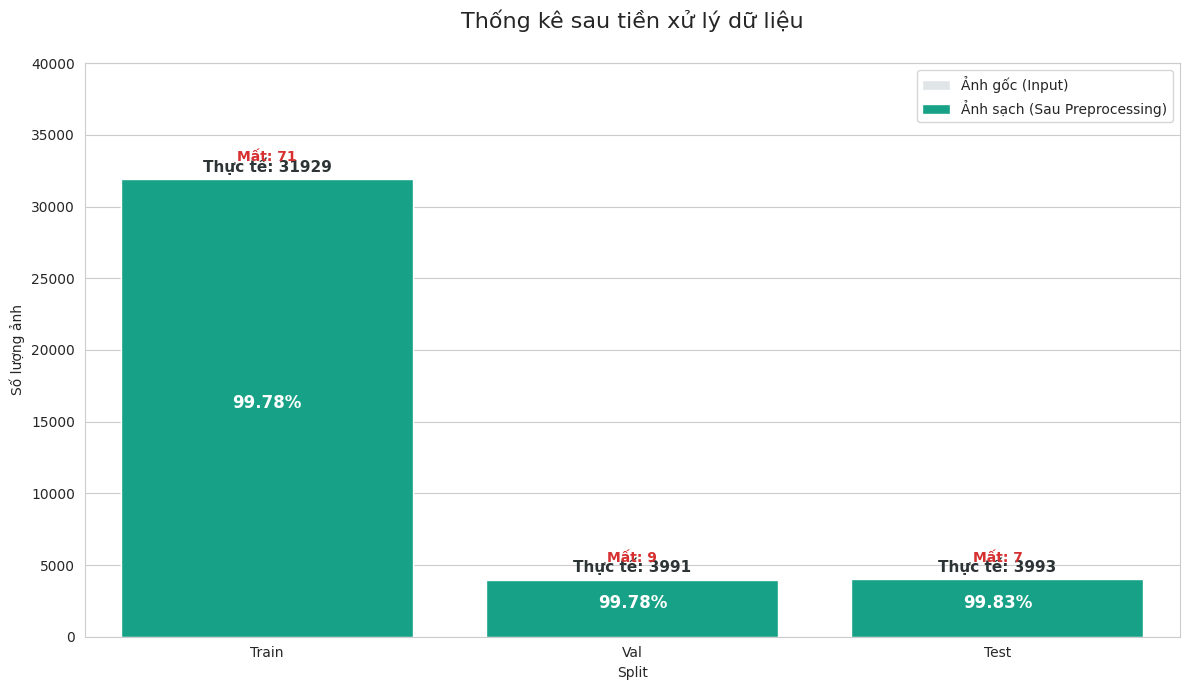


--- BẢNG TỔNG HỢP SỐ LIỆU ---
Split  Original  Processed  Dropped  Retention_Rate
Train     32000      31929       71       99.778125
  Val      4000       3991        9       99.775000
 Test      4000       3993        7       99.825000


In [ ]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

jsonl_paths = {
    "Train": "/content/drive/MyDrive/LayoutLM_Project/processed_data/train_metadata.jsonl",
    "Val": "/content/drive/MyDrive/LayoutLM_Project/processed_data/val_metadata.jsonl",
    "Test": "/content/drive/MyDrive/LayoutLM_Project/processed_data/test_metadata.jsonl"
}

original_counts = {
    "Train": 32000,
    "Val": 4000,
    "Test": 4000
}

def count_lines(file_path):
    if not os.path.exists(file_path):
        print(f"⚠️ Cảnh báo: Không tìm thấy file {file_path}")
        return 0
    with open(file_path, 'r', encoding='utf-8') as f:
        return sum(1 for _ in f)

results = []
for split, path in jsonl_paths.items():
    processed = count_lines(path)
    original = original_counts[split]
    results.append({
        "Split": split,
        "Original": original,
        "Processed": processed,
        "Dropped": original - processed,
        "Retention_Rate": (processed / original) * 100
    })

df = pd.DataFrame(results)

# Vẽ biểu đồ
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax = sns.barplot(x='Split', y='Original', data=df, color='#dfe6e9', label='Ảnh gốc (Input)')
sns.barplot(x='Split', y='Processed', data=df, color='#00b894', label='Ảnh sạch (Sau Preprocessing)')

# Thêm số liệu chi tiết trên đầu cột
for i, row in df.iterrows():
    # Hiển thị số ảnh thực tế
    plt.text(i, row['Processed'] + 500, f"Thực tế: {int(row['Processed'])}",
             ha='center', fontsize=11, fontweight='bold', color='#2d3436')

    # Hiển thị số lượng bị mất (Dropped)
    if row['Dropped'] > 0:
        plt.text(i, row['Original'] + 1000, f"Mất: {int(row['Dropped'])}",
                 ha='center', va='bottom', color='#d63031', fontsize=10, fontweight='bold')

    plt.text(i, row['Processed']/2, f"{row['Retention_Rate']:.2f}%",
             ha='center', color='white', fontweight='bold', fontsize=12)

plt.title('Thống kê sau tiền xử lý dữ liệu', fontsize=16, pad=25)
plt.ylabel('Số lượng ảnh')
plt.ylim(0, 40000)
plt.legend()
plt.tight_layout()
plt.show()

print("\n--- BẢNG TỔNG HỢP SỐ LIỆU ---")
print(df.to_string(index=False))

In [ ]:
# Xóa tất cả các file metadata cũ để tránh xung đột định dạng
!rm -rf /content/drive/MyDrive/LayoutLM_Project/processed_data/*.jsonl

# Kiểm tra lại xem đã sạch chưa (nếu hiện trống không là OK)
!ls /content/drive/MyDrive/LayoutLM_Project/processed_data/

ls: cannot access '/content/drive/MyDrive/LayoutLM_Project/processed_data/': No such file or directory


In [ ]:
!find /content/data_subset/train -name "*.tif" | wc -l

32000


In [ ]:
# ── CELL DEBUG — chạy trước Cell 3 để tìm nguyên nhân ──
from pathlib import Path
import json

ROOT_DIR       = Path("/content")
IMAGE_BASE_DIR = Path("/content/data_subset")
OUTPUT_DIR     = Path("/content/drive/MyDrive/LayoutLM_Project/processed_data")

# ── Kiểm tra 1: File JSONL cũ có không? ──────────────────
for split in ["train", "val", "test"]:
    f = OUTPUT_DIR / f"{split}_metadata.jsonl"
    if f.exists():
        lines = f.read_text().strip().splitlines()
        print(f"[{split}] File JSONL CŨ tồn tại: {len(lines)} dòng → đang bị skip hết!")
    else:
        print(f"[{split}] File JSONL chưa có → OK")

print()

# ── Kiểm tra 2: Đường dẫn ảnh có đúng không? ─────────────
label_file = ROOT_DIR / "train.txt"
with open(label_file) as f:
    first_line = f.readline().strip()

rel_path, label = first_line.split()
abs_path = IMAGE_BASE_DIR / rel_path

print(f"Dòng đầu train.txt : {first_line}")
print(f"Đường dẫn ghép    : {abs_path}")
print(f"File tồn tại       : {abs_path.exists()}")   # phải là True

print()

# ── Kiểm tra 3: Thử OCR 1 ảnh thật ───────────────────────
if abs_path.exists():
    import cv2, numpy as np
    from paddleocr import PaddleOCR

    engine = PaddleOCR(use_angle_cls=True, lang="en",
                       use_gpu=True, show_log=False, enable_mkldnn=False)

    img = cv2.imread(str(abs_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print(f"Ảnh shape: {img.shape}")

    result = engine.ocr(img, cls=True)
    if result and result[0]:
        print(f"OCR OK — {len(result[0])} tokens tìm thấy")
        print("3 token đầu:", [(r[1][0], round(r[1][1],2)) for r in result[0][:3]])
    else:
        print("OCR trả về rỗng — ảnh có thể quá mờ hoặc không có text")
else:
    print("❌ File ảnh không tồn tại — đường dẫn sai!")

[train] File JSONL CŨ tồn tại: 0 dòng → đang bị skip hết!
[val] File JSONL CŨ tồn tại: 0 dòng → đang bị skip hết!
[test] File JSONL CŨ tồn tại: 0 dòng → đang bị skip hết!

Dòng đầu train.txt : imagesq/q/o/c/qoc54c00/80035521.tif 15
Đường dẫn ghép    : /content/data_subset/imagesq/q/o/c/qoc54c00/80035521.tif
File tồn tại       : False

❌ File ảnh không tồn tại — đường dẫn sai!


In [ ]:
# ── CELL FIX — chạy cell này, KHÔNG sửa Cell 3 ──

from pathlib import Path

OUTPUT_DIR = Path("/content/drive/MyDrive/LayoutLM_Project/processed_data")

# Fix 1: Xóa các file JSONL rỗng — file 0 dòng khiến resume nghĩ đã xong
for split in ["train", "val", "test"]:
    f = OUTPUT_DIR / f"{split}_metadata.jsonl"
    if f.exists() and f.stat().st_size == 0:
        f.unlink()
        print(f"Đã xóa file rỗng: {f.name}")

# Fix 2: Tìm đường dẫn ảnh thực tế
print("\nTìm thư mục chứa ảnh...")
for p in Path("/content").rglob("*.tif"):
    print(f"Tìm thấy .tif tại: {p}")
    break  # chỉ cần thấy 1 cái để xác định cấu trúc
else:
    print("Không tìm thấy .tif trong /content")
    # Thử tìm rộng hơn
    for p in Path("/content").iterdir():
        print(f"  {p}")

Đã xóa file rỗng: train_metadata.jsonl
Đã xóa file rỗng: val_metadata.jsonl
Đã xóa file rỗng: test_metadata.jsonl

Tìm thư mục chứa ảnh...
Tìm thấy .tif tại: /content/data_subset/test/invoice/0060201834.tif


In [ ]:
# 1. Gỡ sạch các bản cũ để tránh xung đột
!pip uninstall paddlepaddle paddlepaddle-gpu paddleocr paddlex numpy -y

# 2. Cài lại NumPy bản 1.x đầu tiên (Đây là chìa khóa)
!pip install "numpy<2.0"

# 3. Cài đặt các thư viện còn lại
!pip install paddlepaddle-gpu==2.6.1 -i https://pypi.tuna.tsinghua.edu.cn/simple
!pip install paddleocr==2.7.3 transformers tqdm -q

# 4. Yêu cầu Colab khởi động lại hệ thống để nhận NumPy mới
import os
os.kill(os.getpid(), 9)

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 76.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
sh

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 758.8/758.8 MB 36.8 MB/s eta 0:00:01^C


In [ ]:
from pathlib import Path

IMAGE_BASE_DIR = Path("/content/data_subset")

# Xem cấu trúc thực tế
print("=== Cấu trúc /content/data_subset/ ===")
for p in sorted(IMAGE_BASE_DIR.iterdir()):
    print(f"  {p.name}/")
    for sub in sorted(p.iterdir())[:3]:  # 3 subfolder đầu
        count = len(list(sub.glob("*.tif")))
        print(f"    {sub.name}/  ({count} .tif files)")

print()

# Xem nội dung file txt
print("=== 3 dòng đầu train.txt ===")
with open("/content/train.txt") as f:
    for i, line in enumerate(f):
        if i >= 3: break
        print(f"  {line.strip()}")

print()
print("=== 3 dòng đầu val.txt ===")
with open("/content/val.txt") as f:
    for i, line in enumerate(f):
        if i >= 3: break
        print(f"  {line.strip()}")

=== Cấu trúc /content/data_subset/ ===
  pre2.py/


NotADirectoryError: [Errno 20] Not a directory: '/content/data_subset/pre2.py'

In [ ]:
from pathlib import Path

# Tìm tất cả .tif trong /content
print("=== Tất cả .tif tìm thấy (tối đa 5) ===")
count = 0
for p in Path("/content").rglob("*.tif"):
    print(f"  {p}")
    count += 1
    if count >= 5:
        print("  ...")
        break

print()

# Xem cấu trúc /content tổng thể
print("=== Cấu trúc /content/ ===")
for p in sorted(Path("/content").iterdir()):
    if p.is_dir():
        n = sum(1 for _ in p.rglob("*.tif"))
        print(f"  {p.name}/  ({n} .tif)")
    else:
        print(f"  {p.name}")

print()

# Xem 3 dòng đầu train.txt
print("=== 3 dòng đầu train.txt ===")
with open("/content/train.txt") as f:
    for i, line in enumerate(f):
        if i >= 3: break
        print(f"  {line.strip()}")

=== Tất cả .tif tìm thấy (tối đa 5) ===
  /content/data_subset/test/invoice/0060201834.tif
  /content/data_subset/test/invoice/ctrcontracts012295-2.tif
  /content/data_subset/test/invoice/91574456_91574458.tif
  /content/data_subset/test/invoice/2055018945.tif
  /content/data_subset/test/invoice/513263724.tif
  ...

=== Cấu trúc /content/ ===
  .config/  (0 .tif)
  data_subset/  (40000 .tif)
  drive/  (0 .tif)
  sample_data/  (0 .tif)
  test.txt
  train.txt
  val.txt

=== 3 dòng đầu train.txt ===
  imagesq/q/o/c/qoc54c00/80035521.tif 15
  imagese/e/w/c/ewc23d00/513280028.tif 1
  imagesw/w/b/t/wbt26e00/2053453161.tif 7


In [ ]:
# ── CELL FIX MAPPING — chạy cell này thay cho load_tasks() cũ ──
from pathlib import Path
import json
from tqdm import tqdm

ROOT_DIR       = Path("/content")
IMAGE_BASE_DIR = Path("/content/data_subset")
OUTPUT_DIR     = Path("/content/drive/MyDrive/LayoutLM_Project/processed_data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Bước 1: Index toàn bộ .tif theo filename (không cần path đầy đủ) ─────────
print("Đang index ảnh...")
filename_to_path = {}
for p in IMAGE_BASE_DIR.rglob("*.tif"):
    filename_to_path[p.name] = p
print(f"Tổng số ảnh index được: {len(filename_to_path)}")

# ── Bước 2: Xem thử class name → label id mapping ─────────────────────────────
# data_subset/train/invoice/... → class name là "invoice"
# Cần biết tên folder class để map sang label int trong file txt
print("\nCác class folder tìm thấy:")
class_folders = set()
for p in IMAGE_BASE_DIR.rglob("*.tif"):
    # cấu trúc: data_subset/{split}/{class}/{file.tif}
    class_folders.add(p.parent.name)
for c in sorted(class_folders):
    print(f"  {c}")

# ── Bước 3: Thử map 5 dòng đầu train.txt ─────────────────────────────────────
print("\nThử map 5 dòng đầu train.txt:")
with open(ROOT_DIR / "train.txt") as f:
    for i, line in enumerate(f):
        if i >= 5: break
        rel_path, label = line.strip().split()
        fname = Path(rel_path).name          # lấy chỉ tên file: 80035521.tif
        found = filename_to_path.get(fname)
        status = "✅" if found else "❌ không tìm thấy"
        print(f"  {fname} → {status}")
        if found:
            print(f"    thực tế: {found}")

Đang index ảnh...
Tổng số ảnh index được: 40000

Các class folder tìm thấy:
  advertisement
  budget
  email
  file_folder
  form
  handwritten
  invoice
  letter
  memo
  news_article
  presentation
  questionnaire
  resume
  scientific_publication
  scientific_report
  specification

Thử map 5 dòng đầu train.txt:
  80035521.tif → ❌ không tìm thấy
  513280028.tif → ❌ không tìm thấy
  2053453161.tif → ❌ không tìm thấy
  2040792992_2040792994.tif → ❌ không tìm thấy
  522787731+-7732.tif → ✅
    thực tế: /content/data_subset/train/handwritten/522787731+-7732.tif


In [ ]:
# ── CELL: Build mapping từ folder structure ───────────────────────────────────

from pathlib import Path
import json
from tqdm import tqdm
from paddleocr import PaddleOCR
import cv2, re, unicodedata

ROOT_DIR       = Path("/content")
IMAGE_BASE_DIR = Path("/content/data_subset")
OUTPUT_DIR     = Path("/content/drive/MyDrive/LayoutLM_Project/processed_data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 16 class của RVL-CDIP, đúng thứ tự label 0-15
CLASS_TO_LABEL = {
    "letter": 0, "form": 1, "email": 2, "handwritten": 3,
    "advertisement": 4, "scientific_report": 5, "scientific_publication": 6,
    "specification": 7, "file_folder": 8, "news_article": 9,
    "budget": 10, "invoice": 11, "presentation": 12,
    "questionnaire": 13, "resume": 14, "memo": 15,
}

# ── Kiểm tra mapping class ────────────────────────────────────────────────────
print("=== Kiểm tra class mapping ===")
found_classes = set()
for p in IMAGE_BASE_DIR.rglob("*.tif"):
    found_classes.add(p.parent.name)

for c in sorted(found_classes):
    label = CLASS_TO_LABEL.get(c, "❌ KHÔNG CÓ TRONG MAP")
    print(f"  {c:30s} → {label}")

print()

# ── Build task list từ folder structure ──────────────────────────────────────
def build_tasks_from_folders(split: str) -> list[tuple]:
    """
    Đọc trực tiếp từ data_subset/{split}/{class_name}/*.tif
    Trả về list (abs_path, rel_path, label_str)
    """
    split_dir = IMAGE_BASE_DIR / split
    if not split_dir.exists():
        print(f"  ❌ Không tìm thấy: {split_dir}")
        return []

    tasks = []
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        label = CLASS_TO_LABEL.get(class_dir.name)
        if label is None:
            print(f"  ⚠️  Class không nhận dạng được: {class_dir.name}")
            continue
        for img_path in class_dir.glob("*.tif"):
            rel = img_path.relative_to(IMAGE_BASE_DIR)
            tasks.append((str(img_path), str(rel), str(label)))

    print(f"  [{split}] {len(tasks)} ảnh từ {split_dir}")
    return tasks

print("=== Kiểm tra số lượng ảnh mỗi split ===")
for split in ["train", "val", "test"]:
    build_tasks_from_folders(split)

=== Kiểm tra class mapping ===
  advertisement                  → 4
  budget                         → 10
  email                          → 2
  file_folder                    → 8
  form                           → 1
  handwritten                    → 3
  invoice                        → 11
  letter                         → 0
  memo                           → 15
  news_article                   → 9
  presentation                   → 12
  questionnaire                  → 13
  resume                         → 14
  scientific_publication         → 6
  scientific_report              → 5
  specification                  → 7

=== Kiểm tra số lượng ảnh mỗi split ===
  [train] 32000 ảnh từ /content/data_subset/train
  [val] 4000 ảnh từ /content/data_subset/val
  [test] 4000 ảnh từ /content/data_subset/test


In [ ]:
# 1. Ép hạ cấp NumPy và OpenCV để không bị lỗi ABI
!pip install "numpy<2.0" "opencv-python<4.9" --force-reinstall -q

# 2. Cài đặt cặp bài trùng ổn định nhất cho PaddleOCR
!pip install paddlepaddle-gpu==2.6.1 -i https://pypi.tuna.tsinghua.edu.cn/simple -q
!pip install paddleocr==2.7.3 transformers tqdm -q

# 3. Lệnh "khai tử" để Colab nạp lại thư viện (Nghĩa là Restart Runtime tự động)
import os
os.kill(os.getpid(), 9)

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 95, in resolve
    result = self._result = resolver.resolve(
                            ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_vendor/resolvelib/resolvers.py", line 546, in resolve
    state = resolution.resolve(requirements, max_rounds=max_rounds)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 

In [ ]:
# Chạy cell này đầu tiên sau khi Restart
!pip uninstall paddlepaddle paddlepaddle-gpu paddleocr paddlex -y
!pip install paddlepaddle-gpu==2.6.1 -i https://pypi.tuna.tsinghua.edu.cn/simple
!pip install paddleocr==2.7.3  # Bản này cực kỳ ổn định cho LayoutLMv3
!pip install transformers tqdm -q

Found existing installation: paddlepaddle-gpu 2.6.2
Uninstalling paddlepaddle-gpu-2.6.2:
  Successfully uninstalled paddlepaddle-gpu-2.6.2
Found existing installation: paddleocr 3.5.0
Uninstalling paddleocr-3.5.0:
  Successfully uninstalled paddleocr-3.5.0
Found existing installation: paddlex 3.5.1
Uninstalling paddlex-3.5.1:
  Successfully uninstalled paddlex-3.5.1
Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 758.8/758.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.0/780.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 33.0 MB/s eta 0:00:00
   ━━━━━